# 04 — Obesity trend analysis

**Objective.** Analyse published adult obesity estimates and uncertainty.

**Business relevance.** Establish a transparent descriptive evidence base without merging incompatible populations or implying causality.

**Data source.** RKI/GEDA trend publication, Table 2  
**Period.** 2003/04–2023  
**Granularity.** Germany × published survey period × total adult stratum  
**Units.** Percent and 95% confidence interval

Last updated: 2026-08-25

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df=pd.read_csv(DATA/'fact_obesity_observed.csv')
print('Shape:', df.shape)
display(df.head())
display(df.dtypes.to_frame('dtype'))
display(df.describe(include='all').T)
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))

Shape: (9, 15)


,date_key,period_start_year,period_end_year,estimate_pct,ci95_lower_pct,ci95_upper_pct,indicator,population,stratum,unit,source_id,input_class,geography,denominator,method_note
0,2003/2004,2003,2004,12.2,11.5,12.9,Obesity prevalence (BMI >= 30 kg/m2),Adults aged 18+ in Germany,Total,percent,RKI-GEDA-TREND-2025,official survey estimate,Germany,weighted adult survey population,Self-reported height and weight; directly age-...
1,2006,2006,2006,13.7,12.5,15.0,Obesity prevalence (BMI >= 30 kg/m2),Adults aged 18+ in Germany,Total,percent,RKI-GEDA-TREND-2025,official survey estimate,Germany,weighted adult survey population,Self-reported height and weight; directly age-...
2,2009,2009,2009,15.9,15.1,16.6,Obesity prevalence (BMI >= 30 kg/m2),Adults aged 18+ in Germany,Total,percent,RKI-GEDA-TREND-2025,official survey estimate,Germany,weighted adult survey population,Self-reported height and weight; directly age-...
3,2010,2010,2010,15.7,15.0,16.4,Obesity prevalence (BMI >= 30 kg/m2),Adults aged 18+ in Germany,Total,percent,RKI-GEDA-TREND-2025,official survey estimate,Germany,weighted adult survey population,Self-reported height and weight; directly age-...
4,2012,2012,2012,16.3,15.5,17.1,Obesity prevalence (BMI >= 30 kg/m2),Adults aged 18+ in Germany,Total,percent,RKI-GEDA-TREND-2025,official survey estimate,Germany,weighted adult survey population,Self-reported height and weight; directly age-...


,dtype
date_key,object
period_start_year,int64
period_end_year,int64
estimate_pct,float64
ci95_lower_pct,float64
ci95_upper_pct,float64
indicator,object
population,object
stratum,object
unit,object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date_key,9,9,2003/2004,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
period_start_year,9.0,NaN,NaN,NaN,2013.111111,7.007932,2003.0,2009.0,2012.0,2019.0,2023.0
period_end_year,9.0,NaN,NaN,NaN,2013.444444,6.966188,2004.0,2009.0,2012.0,2020.0,2023.0
estimate_pct,9.0,NaN,NaN,NaN,16.566667,2.50998,12.2,15.7,16.3,18.8,19.7
ci95_lower_pct,9.0,NaN,NaN,NaN,15.733333,2.519425,11.5,15.0,15.5,18.0,18.6
ci95_upper_pct,9.0,NaN,NaN,NaN,17.444444,2.557397,12.9,16.4,17.1,19.6,21.0
indicator,9,1,Obesity prevalence (BMI >= 30 kg/m2),9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population,9,1,Adults aged 18+ in Germany,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stratum,9,1,Total,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit,9,1,percent,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values: 0
Duplicate rows: 0


In [3]:
start=df.iloc[0].estimate_pct; end=df.iloc[-1].estimate_pct
absolute=end-start; relative=(end/start-1)*100
print(f'Absolute change: {absolute:.1f} percentage points')
print(f'Relative change: {relative:.1f}%')
display(df[['date_key','estimate_pct','ci95_lower_pct','ci95_upper_pct']])

Absolute change: 7.5 percentage points
Relative change: 61.5%


,date_key,estimate_pct,ci95_lower_pct,ci95_upper_pct
0,2003/2004,12.2,11.5,12.9
1,2006,13.7,12.5,15.0
2,2009,15.9,15.1,16.6
3,2010,15.7,15.0,16.4
4,2012,16.3,15.5,17.1
5,2014/2015,18.0,17.3,18.8
6,2019/2020,18.8,18.0,19.6
7,2022,18.8,18.1,19.6
8,2023,19.7,18.6,21.0


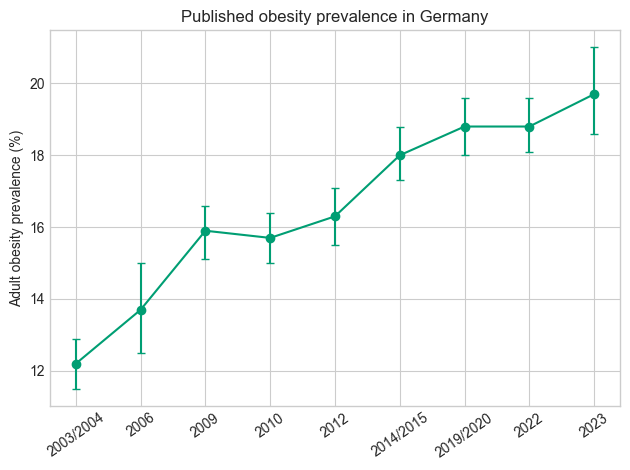

In [4]:
x=range(len(df)); yerr=[df.estimate_pct-df.ci95_lower_pct,df.ci95_upper_pct-df.estimate_pct]
plt.errorbar(x,df.estimate_pct,yerr=yerr,marker='o',color='#009E73',capsize=3); plt.xticks(x,df.date_key,rotation=35); plt.ylabel('Adult obesity prevalence (%)'); plt.title('Published obesity prevalence in Germany'); plt.tight_layout(); plt.show()

## Interpretation

Published prevalence rose from 12.2% to 19.7%, an absolute increase of 7.5 percentage points. Estimates use self-reported height and weight in weighted, directly age-standardized adult survey populations. Composite periods are not interpolated, and no reliable sex or Bundesland cross-filter is created.

## Limitations, outputs and conclusion

The analysis preserves source periods, units and denominators; it does not impute, interpolate or claim causality. Outputs are the displayed summary tables and Matplotlib figures. The conclusion is descriptive and should be read with the source-specific limitations above.

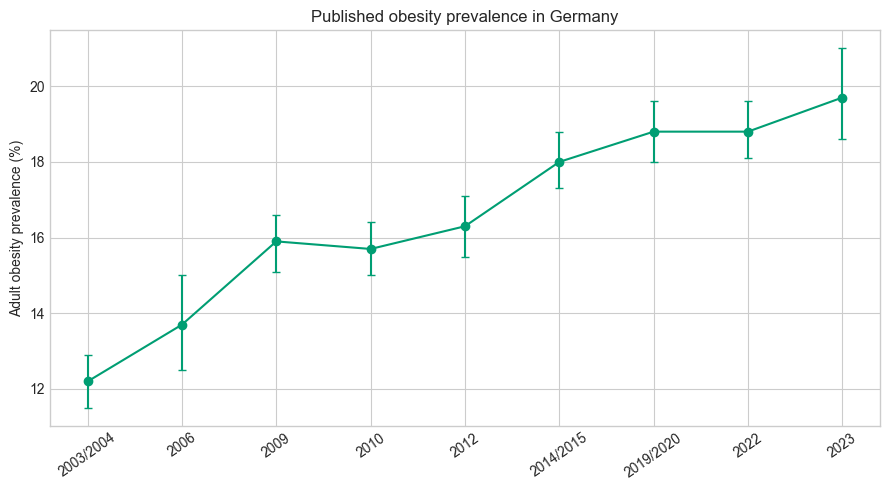

In [5]:
IMAGE_DIR = ROOT / 'images' / 'obesity'; IMAGE_DIR.mkdir(parents=True, exist_ok=True)
x=range(len(df)); yerr=[df.estimate_pct-df.ci95_lower_pct,df.ci95_upper_pct-df.estimate_pct]
plt.figure(figsize=(9,5)); plt.errorbar(x,df.estimate_pct,yerr=yerr,marker='o',color='#009E73',capsize=3); plt.xticks(x,df.date_key,rotation=35); plt.ylabel('Adult obesity prevalence (%)'); plt.title('Published obesity prevalence in Germany'); plt.tight_layout(); plt.savefig(IMAGE_DIR/'obesity_prevalence_trend.png',dpi=180); plt.show()
